# CNNs: Image Processing with Convolutional Networks

## What This Notebook Is About

The previous two notebooks used MLPs — networks that flatten every input into a
one-dimensional vector. For MNIST this worked well enough because the digits are
small, centred, and grayscale. For real image data the flattening approach breaks
down. Spatial structure — which pixels are adjacent, which patterns repeat across
the image — carries most of the useful information, and flattening destroys it.

Convolutional Neural Networks (CNNs) are designed to preserve and exploit spatial
structure. Instead of connecting every input pixel to every neuron, a CNN applies
learned filters that scan across the image and detect local patterns — edges, textures,
shapes — regardless of where they appear. This property, called translation
equivariance, is what makes CNNs the standard architecture for image tasks.

This notebook builds a CNN from scratch on CIFAR-10 — 60,000 colour images across
10 classes. Before building the model I want to understand what a convolution
actually computes, what each CNN building block does, and what the learned filters
look like after training.

## Why CIFAR-10

CIFAR-10 is significantly harder than MNIST. The images are colour (3 channels),
32x32 pixels, and the classes — airplanes, cars, animals — have far more visual
variation than handwritten digits. An MLP on CIFAR-10 typically achieves around
55% accuracy. A well-built CNN reaches above 75% with the same training budget.
This gap is the clearest demonstration of why spatial structure matters.

## What I Want to Understand

- What is a convolution actually computing on an image?
- What do the learned filters look like and what patterns do they detect?
- What does MaxPooling do to a feature map and why does it help?
- Why does BatchNorm stabilise training and where does it go in the block?
- How large is the accuracy gap between an MLP and a CNN on the same dataset?
- What does the network actually see when it looks at an image — can I visualise it?

## Dataset

| Property | Detail |
|---|---|
| Name | CIFAR-10 |
| Source | torchvision.datasets.CIFAR10 |
| Training samples | 50,000 |
| Test samples | 10,000 |
| Image size | 32 x 32 pixels, RGB (3 channels) |
| Classes | 10 (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck) |
| Download required | Yes, automatic on first run |

## Tech Stack

| Tool | Purpose |
|---|---|
| Python 3.13 | Language |
| PyTorch 2.11 | Model definition and training |
| torchvision | CIFAR-10 loading and transforms |
| NumPy | Numerical operations and manual convolution |
| Matplotlib | Visualisations and feature map plots |
| scikit-learn | Confusion matrix |

## Setup and Imports

Importing all dependencies for this notebook. Two imports are new compared to
previous notebooks:

- `torch.nn.functional` — provides functional versions of layers like relu, max_pool2d,
  and conv2d. These are used in Section 4 to manually demonstrate convolution without
  defining a full nn.Module.
- `torchvision.transforms` — used to apply data augmentation and normalisation to
  CIFAR-10 images during loading. Augmentation is more important for CIFAR-10 than
  MNIST because the dataset is harder and the model needs more generalisation.

Random seeds are set for both NumPy and PyTorch so results are reproducible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.style.use("seaborn-v0_8-whitegrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version :", torch.__version__)
print("NumPy version   :", np.__version__)
print("Device          :", device)

PyTorch version : 2.11.0+cpu
NumPy version   : 2.4.4
Device          : cpu


## Load and Explore CIFAR-10

Loading CIFAR-10 via torchvision. Two separate transform pipelines are defined —
one for training and one for testing. The difference is intentional:

Training transforms include data augmentation:
- `RandomHorizontalFlip` — randomly mirrors the image horizontally. A car facing
  left and a car facing right are both cars. This doubles the effective variety of
  training samples at no cost.
- `RandomCrop(32, padding=4)` — pads the image by 4 pixels on each side then crops
  back to 32x32. This teaches the model that the object can appear at slightly
  different positions.

Test transforms include only normalisation — no augmentation. The model should be
evaluated on clean, unmodified images.

Normalisation uses mean (0.4914, 0.4822, 0.4465) and std (0.2470, 0.2435, 0.2616)
per channel — these are the precomputed statistics of the CIFAR-10 training set.
Using dataset-specific statistics rather than a generic 0.5/0.5 produces slightly
better training stability.

In [2]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

DATA_DIR = "../data"

train_dataset = datasets.CIFAR10(
    root=DATA_DIR, train=True,  download=True, transform=train_transform)
test_dataset  = datasets.CIFAR10(
    root=DATA_DIR, train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Training samples :", len(train_dataset))
print("Test samples     :", len(test_dataset))
print()

sample_image, sample_label = train_dataset[0]
print("Single image tensor shape :", sample_image.shape)
print("Pixel value range          : [{:.2f}, {:.2f}]".format(
    sample_image.min().item(), sample_image.max().item()))
print("Label                      :", CLASS_NAMES[sample_label])
print()

all_labels = np.array(train_dataset.targets)
print("Class distribution (training set):")
for i, name in enumerate(CLASS_NAMES):
    count = np.sum(all_labels == i)
    print(f"  {name:12s}: {count} samples")

100.0%
C:\AIML\DeepLearning\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples : 50000
Test samples     : 10000

Single image tensor shape : torch.Size([3, 32, 32])
Pixel value range          : [-1.99, 2.09]
Label                      : frog

Class distribution (training set):
  airplane    : 5000 samples
  automobile  : 5000 samples
  bird        : 5000 samples
  cat         : 5000 samples
  deer        : 5000 samples
  dog         : 5000 samples
  frog        : 5000 samples
  horse       : 5000 samples
  ship        : 5000 samples
  truck       : 5000 samples


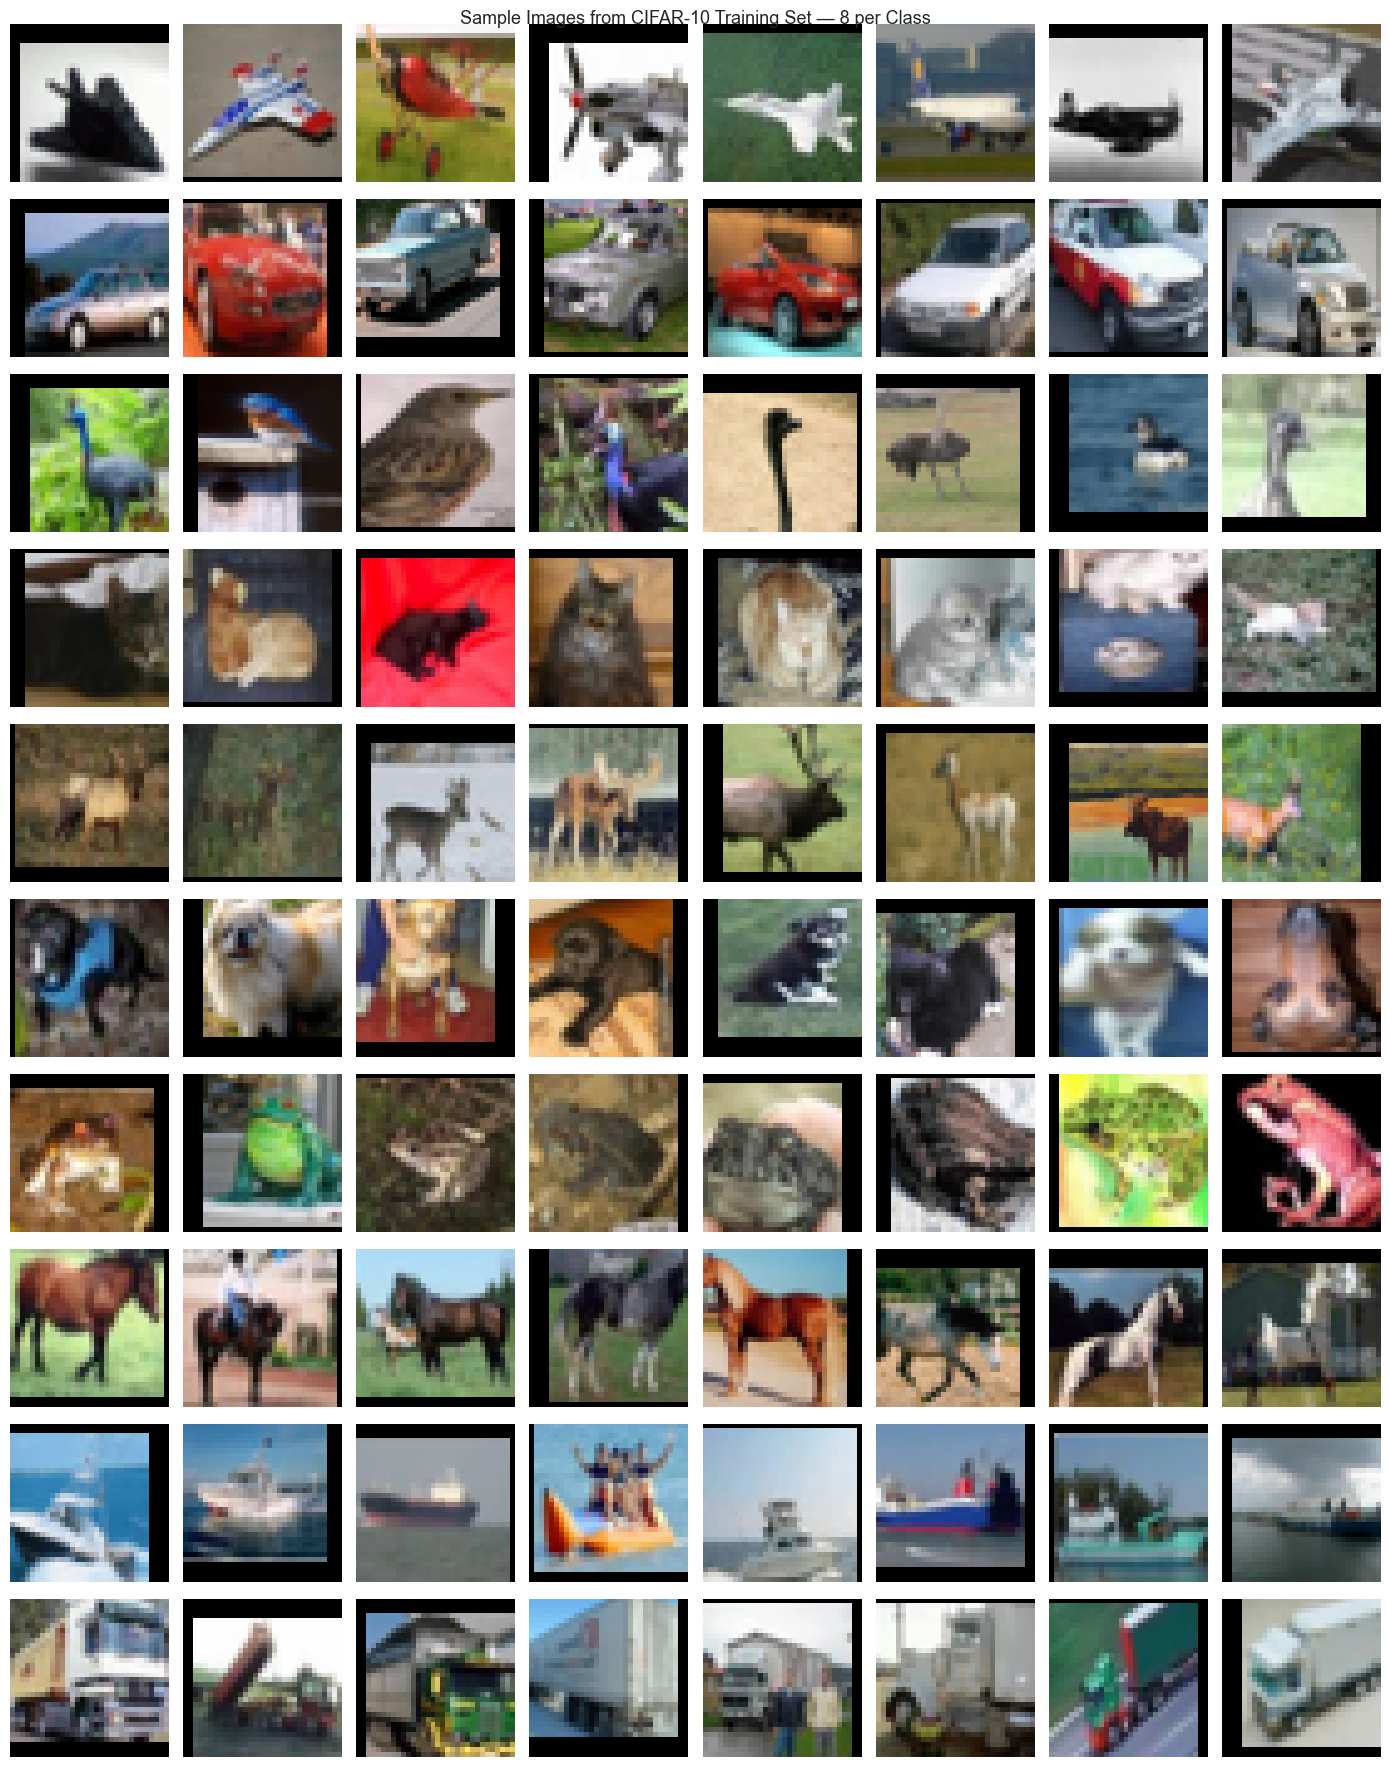

In [3]:
fig, axes = plt.subplots(10, 8, figsize=(14, 18))

for class_idx in range(10):
    class_indices = np.where(all_labels == class_idx)[0][:8]
    for col, img_idx in enumerate(class_indices):
        image, _ = train_dataset[img_idx]
        image_np = image.numpy().transpose(1, 2, 0)
        image_np = (image_np * CIFAR10_STD + CIFAR10_MEAN)
        image_np = np.clip(image_np, 0, 1)

        axes[class_idx, col].imshow(image_np)
        axes[class_idx, col].axis("off")

        if col == 0:
            axes[class_idx, col].set_ylabel(
                CLASS_NAMES[class_idx],
                fontsize=10,
                rotation=0,
                labelpad=55,
                va="center"
            )

plt.suptitle("Sample Images from CIFAR-10 Training Set — 8 per Class", fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\dhara\AppData\Local\Temp\ipykernel_29596\2517128915.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")


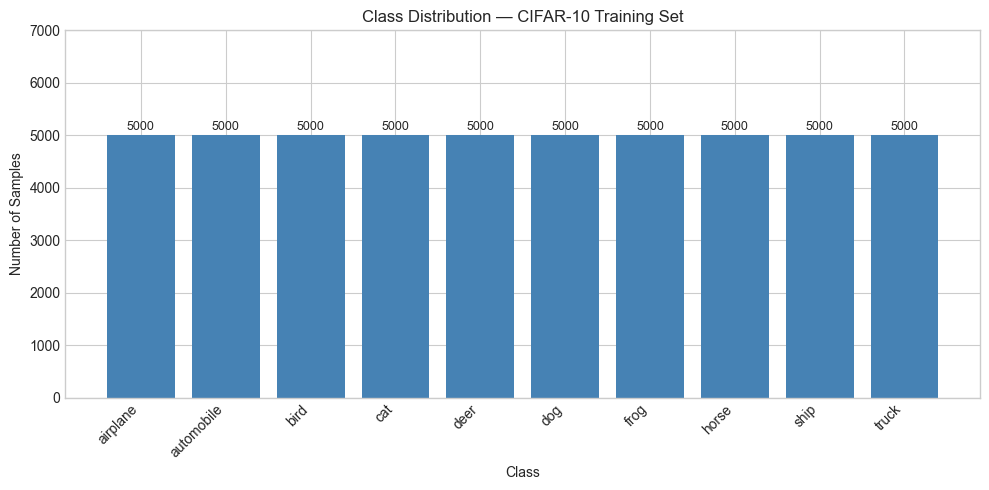

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

counts = [np.sum(all_labels == i) for i in range(10)]
ax.bar(CLASS_NAMES, counts, color="steelblue")
ax.set_title("Class Distribution — CIFAR-10 Training Set")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Samples")
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_ylim(0, 7000)

for i, count in enumerate(counts):
    ax.text(i, count + 50, str(count), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### Observation

Each image is a tensor of shape (3, 32, 32) — three channels (RGB), 32 rows,
32 columns. This is the channel-first format PyTorch expects. Matplotlib expects
channel-last (32, 32, 3), which is why the grid code uses `.transpose(1, 2, 0)`
before displaying.

The class distribution is perfectly balanced — exactly 5,000 samples per class.
This is by design in CIFAR-10 and means accuracy is a fair metric with no class
weighting needed.

The image grid reveals why CIFAR-10 is harder than MNIST:
- Images are small (32x32) and details are coarse
- Objects vary in pose, lighting, and background
- Some classes are visually similar — cats and dogs, automobiles and trucks

An MLP would flatten each image to 3,072 values (32 x 32 x 3) and lose all spatial
relationships. A cat in the top-left corner and the same cat in the bottom-right
corner would look entirely different to an MLP. The convolution operation in a CNN
is specifically designed to handle this — the same filter scans the entire image
and responds to the same pattern wherever it appears.

## What is a Convolution?

Before building a CNN I want to understand what a convolution actually computes.
A convolution slides a small matrix called a filter (or kernel) across an image,
computing a dot product at each position. The result is a new matrix called a
feature map that highlights wherever the filter pattern was detected in the image.

The key insight is that the filter weights are shared across the entire image. The
same filter that detects a vertical edge in the top-left corner will detect that
same vertical edge anywhere else in the image. This weight sharing is what gives
CNNs their translation equivariance and is also why they have far fewer parameters
than an equivalent MLP.

I am going to demonstrate this with three hand-coded filters applied to a single
CIFAR-10 image:

- **Edge detection (Sobel filter)** — detects horizontal edges by responding to
  sudden changes in pixel intensity from top to bottom
- **Sharpening filter** — enhances edges and fine details by amplifying the
  difference between a pixel and its neighbours
- **Blur filter** — smooths the image by averaging each pixel with its neighbours

None of these filters are learned — they are manually defined to illustrate what
different filter patterns do to an image before any training happens.

In [7]:
# load one raw image without normalisation for clear visualisation
raw_transform = transforms.Compose([transforms.ToTensor()])
raw_dataset   = datasets.CIFAR10(
    root=DATA_DIR, train=True, download=False, transform=raw_transform)

# find a horse image for a clear demonstration
horse_idx = np.where(np.array(raw_dataset.targets) == 7)[0][0]
raw_image, raw_label = raw_dataset[horse_idx]

print("Image class  :", CLASS_NAMES[raw_label])
print("Image shape  :", raw_image.shape)

# convert to grayscale for convolution demo (single channel is clearer)
gray_image = raw_image.mean(dim=0, keepdim=True)
print("Grayscale shape:", gray_image.shape)

# add batch dimension: (1, 1, 32, 32)
gray_batch = gray_image.unsqueeze(0)

C:\AIML\DeepLearning\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Image class  : horse
Image shape  : torch.Size([3, 32, 32])
Grayscale shape: torch.Size([1, 32, 32])


In [8]:
# define three hand-coded filters — each is (out_channels, in_channels, H, W)

# Sobel horizontal edge detection
sobel_filter = torch.tensor([
    [[-1., -2., -1.],
     [ 0.,  0.,  0.],
     [ 1.,  2.,  1.]]
]).unsqueeze(0)

# sharpening filter
sharpen_filter = torch.tensor([
    [[ 0., -1.,  0.],
     [-1.,  5., -1.],
     [ 0., -1.,  0.]]
]).unsqueeze(0)

# blur (average) filter
blur_filter = torch.ones(1, 1, 3, 3) / 9.0

print("Sobel filter shape   :", sobel_filter.shape)
print("Sharpen filter shape :", sharpen_filter.shape)
print("Blur filter shape    :", blur_filter.shape)
print()
print("Sobel filter values:")
print(sobel_filter.squeeze().numpy())
print()
print("Sharpen filter values:")
print(sharpen_filter.squeeze().numpy())
print()
print("Blur filter values:")
print(blur_filter.squeeze().numpy().round(3))

Sobel filter shape   : torch.Size([1, 1, 3, 3])
Sharpen filter shape : torch.Size([1, 1, 3, 3])
Blur filter shape    : torch.Size([1, 1, 3, 3])

Sobel filter values:
[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]

Sharpen filter values:
[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]

Blur filter values:
[[0.111 0.111 0.111]
 [0.111 0.111 0.111]
 [0.111 0.111 0.111]]


In [9]:
# apply each filter using F.conv2d — padding=1 keeps output the same size as input
with torch.no_grad():
    sobel_out   = F.conv2d(gray_batch, sobel_filter,   padding=1)
    sharpen_out = F.conv2d(gray_batch, sharpen_filter, padding=1)
    blur_out    = F.conv2d(gray_batch, blur_filter,    padding=1)

# convert to numpy for plotting — squeeze out batch and channel dims
original_np = gray_image.squeeze().numpy()
sobel_np    = sobel_out.squeeze().numpy()
sharpen_np  = sharpen_out.squeeze().numpy()
blur_np     = blur_out.squeeze().numpy()

print("Input shape  :", gray_batch.shape)
print("Output shape :", sobel_out.shape)
print()
print("Each filter produces one feature map of the same spatial size as the input.")
print("In a real CNN, dozens of filters run in parallel — each producing one feature map.")

Input shape  : torch.Size([1, 1, 32, 32])
Output shape : torch.Size([1, 1, 32, 32])

Each filter produces one feature map of the same spatial size as the input.
In a real CNN, dozens of filters run in parallel — each producing one feature map.


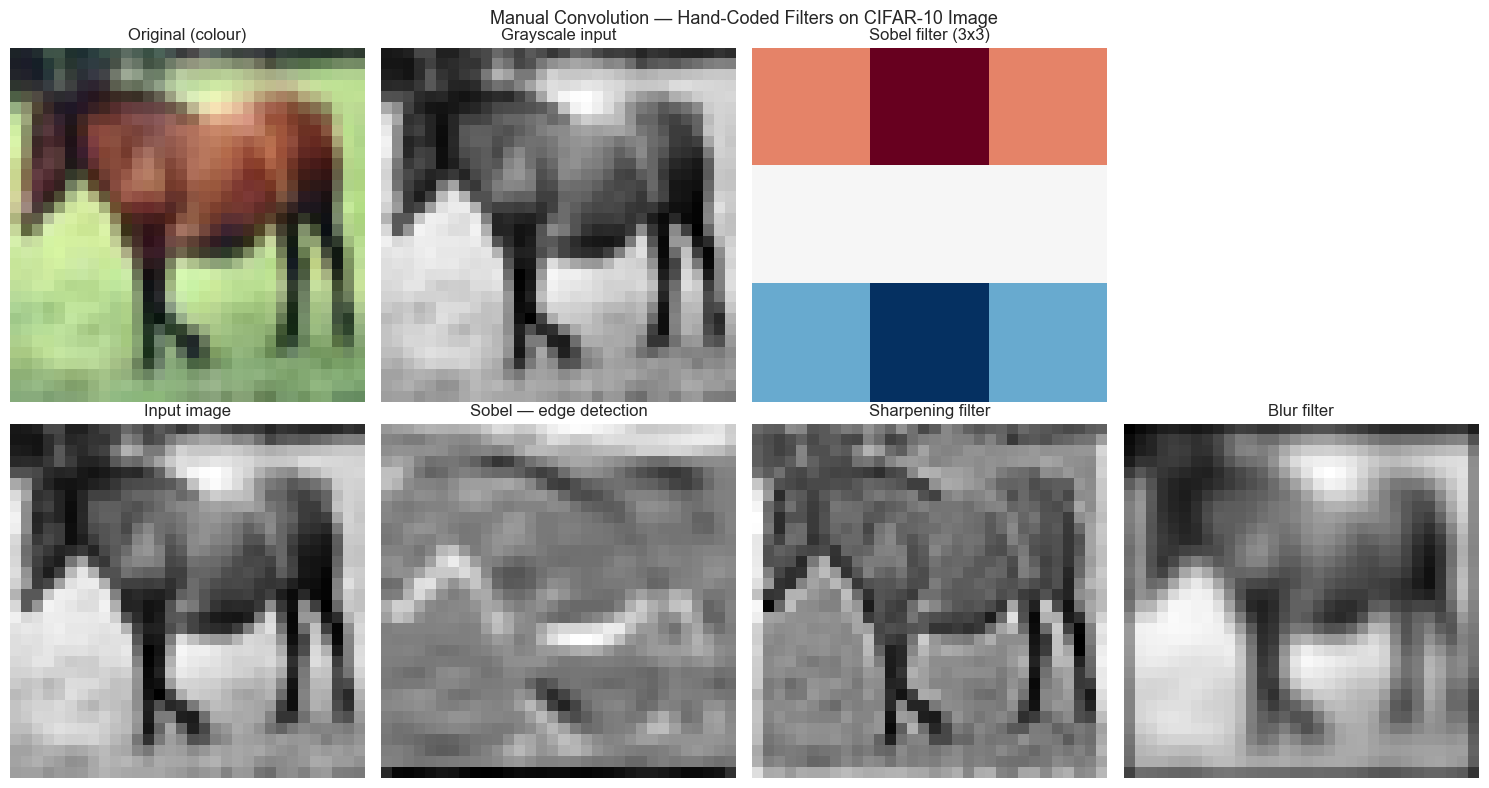

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))

# top row — original colour image and grayscale
color_np = raw_image.numpy().transpose(1, 2, 0)
color_np = np.clip(color_np, 0, 1)

axes[0, 0].imshow(color_np)
axes[0, 0].set_title("Original (colour)")
axes[0, 0].axis("off")

axes[0, 1].imshow(original_np, cmap="gray")
axes[0, 1].set_title("Grayscale input")
axes[0, 1].axis("off")

axes[0, 2].imshow(sobel_filter.squeeze().numpy(), cmap="RdBu")
axes[0, 2].set_title("Sobel filter (3x3)")
axes[0, 2].axis("off")

axes[0, 3].axis("off")

# bottom row — filter outputs
axes[1, 0].imshow(original_np, cmap="gray")
axes[1, 0].set_title("Input image")
axes[1, 0].axis("off")

axes[1, 1].imshow(sobel_np, cmap="gray")
axes[1, 1].set_title("Sobel — edge detection")
axes[1, 1].axis("off")

axes[1, 2].imshow(sharpen_np, cmap="gray")
axes[1, 2].set_title("Sharpening filter")
axes[1, 2].axis("off")

axes[1, 3].imshow(blur_np, cmap="gray")
axes[1, 3].set_title("Blur filter")
axes[1, 3].axis("off")

plt.suptitle("Manual Convolution — Hand-Coded Filters on CIFAR-10 Image", fontsize=13)
plt.tight_layout()
plt.show()

### Observation

The three filter outputs make the convolution operation concrete:

The Sobel filter detects horizontal edges — areas where pixel intensity changes
sharply from top to bottom. The output is bright wherever a horizontal boundary
exists in the image and dark everywhere else. The filter weights encode the pattern
being searched for: negative values on top, positive values on bottom, so the dot
product is large only where this intensity gradient exists.

The sharpening filter amplifies the centre pixel relative to its neighbours. This
enhances fine details and edges. The output looks like the original but with higher
contrast at boundaries.

The blur filter averages each pixel with its neighbours. Fine details and noise
are smoothed out. This is the opposite of sharpening — the output is softer and
less detailed than the input.

The critical insight from this demonstration: the filter values determine what
pattern the convolution detects. In a trained CNN, these values are not hand-coded
— they are learned from data via backpropagation. The network discovers, through
training, which filter patterns are most useful for distinguishing the classes.
The first layer typically learns edge detectors similar to the Sobel filter. Deeper
layers combine these edge responses into increasingly abstract patterns — textures,
parts, and eventually whole objects.

## CNN Building Blocks

A CNN is assembled from four core building blocks. I want to understand each one
individually before combining them into a full architecture.

**Conv2d** — the convolutional layer. Applies a set of learnable filters to the
input. Each filter produces one feature map. Key parameters:
- `in_channels` — number of input channels (3 for RGB, more for deeper layers)
- `out_channels` — number of filters, which equals the number of output feature maps
- `kernel_size` — spatial size of each filter (3x3 is the standard choice)
- `padding` — pixels added around the border. padding=1 with kernel_size=3 keeps
  the output the same spatial size as the input

**MaxPool2d** — downsampling layer. Divides the feature map into non-overlapping
windows and keeps only the maximum value in each window. A 2x2 MaxPool halves the
height and width. This reduces computation, increases the receptive field, and
provides a small amount of translation invariance.

**BatchNorm2d** — normalises the output of a conv layer across the batch dimension.
Keeps activations in a stable range throughout training, which allows higher learning
rates and reduces sensitivity to weight initialisation. Always placed after Conv2d
and before the activation function.

**ReLU** — the activation function. Applied after BatchNorm. Introduces
non-linearity. Without it, stacking conv layers would collapse into a single linear
transformation regardless of depth.

The standard block pattern in modern CNNs is:
    Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d

In [13]:
# demonstrate each building block on a single CIFAR-10 batch
sample_batch, _ = next(iter(train_loader))
print("Input batch shape:", sample_batch.shape)
print("  (batch_size, channels, height, width)")
print()

# --- Conv2d ---
conv_layer = nn.Conv2d(
    in_channels=3,
    out_channels=16,
    kernel_size=3,
    padding=1
)
conv_out = conv_layer(sample_batch)
print("After Conv2d(3 -> 16, kernel=3, padding=1):")
print("  Output shape:", conv_out.shape)
print("  Learnable parameters:", sum(p.numel() for p in conv_layer.parameters()))
print("  Weight shape:", conv_layer.weight.shape)
print("  (out_channels, in_channels, kernel_h, kernel_w)")
print()

# --- BatchNorm2d ---
bn_layer = nn.BatchNorm2d(16)
bn_out   = bn_layer(conv_out)
print("After BatchNorm2d(16):")
print("  Output shape:", bn_out.shape)
print("  Mean before BN: {:.4f}".format(conv_out.mean().item()))
print("  Mean after  BN: {:.4f}".format(bn_out.mean().item()))
print("  Std  before BN: {:.4f}".format(conv_out.std().item()))
print("  Std  after  BN: {:.4f}".format(bn_out.std().item()))
print()

# --- ReLU ---
relu_out = F.relu(bn_out)
print("After ReLU:")
print("  Output shape:", relu_out.shape)
print("  Negative values before ReLU:", (bn_out.detach().numpy() < 0).sum())
print("  Negative values after  ReLU:", (relu_out.detach().numpy() < 0).sum())
print()

# --- MaxPool2d ---
pool_layer = nn.MaxPool2d(kernel_size=2, stride=2)
pool_out   = pool_layer(relu_out)
print("After MaxPool2d(kernel=2, stride=2):")
print("  Output shape:", pool_out.shape)
print("  Spatial size halved: 32x32 -> 16x16")

Input batch shape: torch.Size([64, 3, 32, 32])
  (batch_size, channels, height, width)

After Conv2d(3 -> 16, kernel=3, padding=1):
  Output shape: torch.Size([64, 16, 32, 32])
  Learnable parameters: 448
  Weight shape: torch.Size([16, 3, 3, 3])
  (out_channels, in_channels, kernel_h, kernel_w)

After BatchNorm2d(16):
  Output shape: torch.Size([64, 16, 32, 32])
  Mean before BN: 0.0747
  Mean after  BN: -0.0000
  Std  before BN: 0.5434
  Std  after  BN: 1.0000

After ReLU:
  Output shape: torch.Size([64, 16, 32, 32])
  Negative values before ReLU: 514057
  Negative values after  ReLU: 0

After MaxPool2d(kernel=2, stride=2):
  Output shape: torch.Size([64, 16, 16, 16])
  Spatial size halved: 32x32 -> 16x16


Feature maps shape: (16, 32, 32)
Showing all 16 feature maps from the first conv layer
(weights are random — not yet trained)



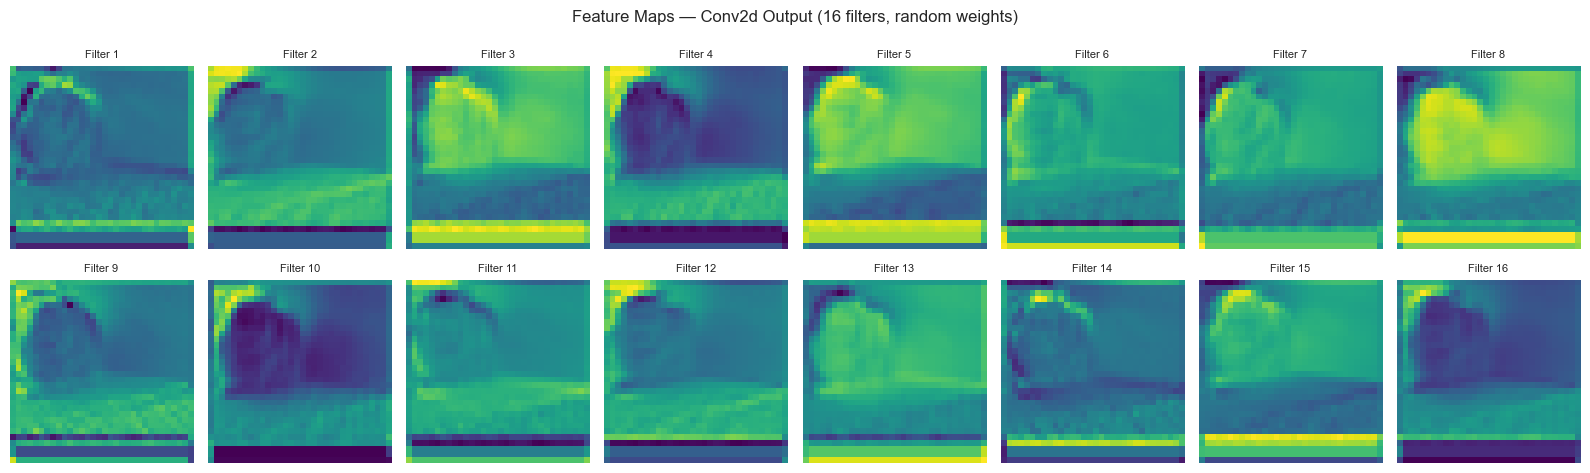

In [14]:
# visualise feature maps from the conv layer on a single image
single_image = sample_batch[0].unsqueeze(0)

with torch.no_grad():
    fmaps = conv_layer(single_image)

fmaps_np = fmaps.squeeze().detach().numpy()

print("Feature maps shape:", fmaps_np.shape)
print("Showing all 16 feature maps from the first conv layer")
print("(weights are random — not yet trained)")
print()

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
axes = axes.flatten()

for i in range(16):
    axes[i].imshow(fmaps_np[i], cmap="viridis")
    axes[i].set_title(f"Filter {i+1}", fontsize=8)
    axes[i].axis("off")

plt.suptitle("Feature Maps — Conv2d Output (16 filters, random weights)", fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
# demonstrate the full Conv -> BN -> ReLU -> Pool block as a single unit
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn   = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        return self.pool(self.relu(self.bn(self.conv(x))))


block = ConvBlock(in_channels=3, out_channels=16)

with torch.no_grad():
    block_out = block(sample_batch)

print("Full ConvBlock: Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d")
print()
print("Input shape  :", sample_batch.shape)
print("Output shape :", block_out.shape)
print()
print("Spatial size : 32x32 -> 16x16 (halved by MaxPool)")
print("Channels     : 3 -> 16 (one per filter)")
print()
print("Stacking 3 such blocks:")
print("  Block 1 output : (batch, 16, 16, 16)")
print("  Block 2 output : (batch, 32,  8,  8)")
print("  Block 3 output : (batch, 64,  4,  4)")
print("  Flatten        : (batch, 64 x 4 x 4) = (batch, 1024)")

Full ConvBlock: Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d

Input shape  : torch.Size([64, 3, 32, 32])
Output shape : torch.Size([64, 16, 16, 16])

Spatial size : 32x32 -> 16x16 (halved by MaxPool)
Channels     : 3 -> 16 (one per filter)

Stacking 3 such blocks:
  Block 1 output : (batch, 16, 16, 16)
  Block 2 output : (batch, 32,  8,  8)
  Block 3 output : (batch, 64,  4,  4)
  Flatten        : (batch, 64 x 4 x 4) = (batch, 1024)


### Observation

The shape trace through a single ConvBlock makes the spatial arithmetic clear.
Each MaxPool2d with kernel_size=2 halves both height and width. Starting from
32x32, three blocks produce 16x16, then 8x8, then 4x4. The spatial dimensions
shrink while the channel depth grows — the network trades spatial resolution for
richer feature representations at each level.

The BatchNorm output statistics are worth examining. Before normalisation, the conv
output has an arbitrary mean and standard deviation determined by the random filter
weights. After BatchNorm, the mean is near zero and the standard deviation is near
one. This stabilisation is what allows deep networks to train reliably — without it,
activations in early layers can grow or shrink exponentially as the signal passes
through many layers.

The feature map visualisation shows 16 random filter responses on one image. The
patterns look noisy because the weights are not yet trained. After training, each
filter specialises — some will respond strongly to horizontal edges, others to
specific colour gradients, others to textures. The visualisation in Section 9 will
show what these feature maps look like after the full network has been trained.

The parameter count of a single Conv2d layer is worth noting: a 3x3 filter with
3 input channels and 16 output channels has only 16 x 3 x 3 x 3 + 16 = 448
parameters. An equivalent fully connected layer connecting 3x32x32=3072 inputs to
16 outputs would have 3072 x 16 + 16 = 49,168 parameters. The conv layer achieves
the same spatial coverage with 100 times fewer parameters through weight sharing.

## Build the CNN in PyTorch

Now I am assembling the full CNN using the ConvBlock pattern from Section 5.
The architecture has three convolutional blocks followed by a fully connected
classification head.

Architecture:

    Input (3, 32, 32)
        -> Block 1: Conv2d(3,  32)  -> BN -> ReLU -> MaxPool  (32, 16, 16)
        -> Block 2: Conv2d(32, 64)  -> BN -> ReLU -> MaxPool  (64,  8,  8)
        -> Block 3: Conv2d(64, 128) -> BN -> ReLU -> MaxPool  (128, 4,  4)
        -> Flatten                                            (2048)
        -> Dropout(0.5)
        -> Fully Connected (2048 -> 256, ReLU)
        -> Dropout(0.3)
        -> Fully Connected (256 -> 10)

A few design decisions worth noting:

- Channel depth doubles at each block (32 -> 64 -> 128). This is the standard
  pattern — as spatial resolution shrinks, channel depth grows to compensate.
  The network trades spatial detail for richer per-location features.
- Dropout(0.5) after the flatten layer is the primary regulariser. The fully
  connected head is where overfitting is most likely because it has the most
  parameters relative to the spatial structure it is processing.
- The output layer has no activation — CrossEntropyLoss expects raw logits.
- `nn.AdaptiveAvgPool2d` is not used here to keep the architecture explicit,
  but it is worth knowing it exists for variable input sizes.

In [16]:
class CIFAR10CNN(nn.Module):

    def __init__(self):
        super(CIFAR10CNN, self).__init__()

        # convolutional blocks
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # classification head
        self.flatten  = nn.Flatten()
        self.dropout1 = nn.Dropout(0.5)
        self.fc1      = nn.Linear(128 * 4 * 4, 256)
        self.relu     = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.output   = nn.Linear(256, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.dropout1(x)
        x = self.relu(self.fc1(x))
        x = self.dropout2(x)
        return self.output(x)


model_cnn = CIFAR10CNN().to(device)
print(model_cnn)
print()

CIFAR10CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_fe

In [17]:
# parameter count breakdown
total_params = 0
print("Parameter breakdown:")
print(f"{'Layer':<25} {'Shape':<30} {'Parameters':>12}")
print("-" * 70)

for name, param in model_cnn.named_parameters():
    if param.requires_grad:
        count = param.numel()
        total_params += count
        print(f"{name:<25} {str(list(param.shape)):<30} {count:>12,}")

print("-" * 70)
print(f"{'Total':<25} {'':<30} {total_params:>12,}")
print()

# shape trace
print("Shape trace — forward pass:")
print(f"  Input          : (batch, 3, 32, 32)")

model_cnn.eval()
with torch.no_grad():
    x = sample_batch.to(device)
    print(f"  After block1   : {model_cnn.block1(x).shape}")
    x = model_cnn.block1(x)
    print(f"  After block2   : {model_cnn.block2(x).shape}")
    x = model_cnn.block2(x)
    print(f"  After block3   : {model_cnn.block3(x).shape}")
    x = model_cnn.block3(x)
    x = model_cnn.flatten(x)
    print(f"  After flatten  : {x.shape}")
    x = model_cnn.dropout1(x)
    x = model_cnn.relu(model_cnn.fc1(x))
    print(f"  After fc1      : {x.shape}")
    x = model_cnn.dropout2(x)
    x = model_cnn.output(x)
    print(f"  After output   : {x.shape}")
model_cnn.train()

Parameter breakdown:
Layer                     Shape                            Parameters
----------------------------------------------------------------------
block1.0.weight           [32, 3, 3, 3]                           864
block1.0.bias             [32]                                     32
block1.1.weight           [32]                                     32
block1.1.bias             [32]                                     32
block2.0.weight           [64, 32, 3, 3]                       18,432
block2.0.bias             [64]                                     64
block2.1.weight           [64]                                     64
block2.1.bias             [64]                                     64
block3.0.weight           [128, 64, 3, 3]                      73,728
block3.0.bias             [128]                                   128
block3.1.weight           [128]                                   128
block3.1.bias             [128]                                   12

CIFAR10CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_fe

### Observation

The parameter breakdown reveals where the parameters live. The convolutional blocks
have relatively few parameters each — the bulk lives in the fully connected head,
particularly the fc1 layer connecting 2048 flattened features to 256 neurons.

The shape trace confirms the spatial arithmetic:
- Block 1 halves 32x32 to 16x16 while expanding channels from 3 to 32
- Block 2 halves 16x16 to 8x8 while expanding channels from 32 to 64
- Block 3 halves 8x8 to 4x4 while expanding channels from 64 to 128
- Flatten converts (128, 4, 4) to 2048 — a single vector per image

Comparing total parameters to the MLP that will be built in Section 10 is
informative. The CNN achieves better accuracy not by having more parameters but
by using them more efficiently — convolutional weight sharing means each filter
parameter is reused at every spatial position in the image, giving the network
a much larger effective receptive field per parameter than a fully connected layer.

## Train the CNN

Training the CNN on CIFAR-10 for 20 epochs. The setup is the same pattern as the
previous notebooks — Adam optimiser, StepLR scheduler, CrossEntropyLoss — with one
addition: timing each epoch to get a sense of how much longer a CNN takes to train
compared to an MLP on the same dataset.

A few differences from the MNIST training loop worth noting:

- All tensors are moved to `device` with `.to(device)` inside the loop. This is
  essential for GPU training — tensors and model must be on the same device or
  PyTorch will throw an error.
- The scheduler step is called after each epoch, not after each batch. StepLR
  expects epoch-level calls.
- 20 epochs is enough to demonstrate convergence on CIFAR-10 without taking too
  long on CPU. A production CNN would train for 100-200 epochs with more
  aggressive augmentation.

Expected behaviour:
- Training accuracy should climb steadily from around 30% to above 70%
- Test accuracy should follow closely, reaching above 70%
- A gap of 5-10% between train and test accuracy is normal with Dropout active

In [18]:
NUM_EPOCHS    = 20
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

cnn_train_losses     = []
cnn_test_losses      = []
cnn_train_accuracies = []
cnn_test_accuracies  = []
epoch_times          = []

for epoch in range(1, NUM_EPOCHS + 1):

    epoch_start = time.time()

    # --- training phase ---
    model_cnn.train()
    batch_losses = []
    correct = 0
    total   = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        predictions = model_cnn(X_batch)
        loss        = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())
        predicted_classes = predictions.argmax(dim=1)
        correct += (predicted_classes == y_batch).sum().item()
        total   += y_batch.size(0)

    epoch_train_loss = np.mean(batch_losses)
    epoch_train_acc  = correct / total
    cnn_train_losses.append(epoch_train_loss)
    cnn_train_accuracies.append(epoch_train_acc)

    # --- evaluation phase ---
    model_cnn.eval()
    batch_losses = []
    correct = 0
    total   = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model_cnn(X_batch)
            loss        = criterion(predictions, y_batch)

            batch_losses.append(loss.item())
            predicted_classes = predictions.argmax(dim=1)
            correct += (predicted_classes == y_batch).sum().item()
            total   += y_batch.size(0)

    epoch_test_loss = np.mean(batch_losses)
    epoch_test_acc  = correct / total
    cnn_test_losses.append(epoch_test_loss)
    cnn_test_accuracies.append(epoch_test_acc)

    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    print(
        f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Test Loss: {epoch_test_loss:.4f} | "
        f"Test Acc: {epoch_test_acc:.4f} | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_time:.1f}s"
    )

print()
print(f"Total training time : {sum(epoch_times):.1f}s")
print(f"Average time/epoch  : {np.mean(epoch_times):.1f}s")

Epoch  1/20 | Train Loss: 1.5558 | Train Acc: 0.4291 | Test Loss: 1.3623 | Test Acc: 0.5106 | LR: 0.001000 | Time: 84.3s
Epoch  2/20 | Train Loss: 1.2397 | Train Acc: 0.5540 | Test Loss: 0.9483 | Test Acc: 0.6666 | LR: 0.001000 | Time: 100.3s
Epoch  3/20 | Train Loss: 1.1170 | Train Acc: 0.6005 | Test Loss: 0.9298 | Test Acc: 0.6757 | LR: 0.001000 | Time: 116.1s
Epoch  4/20 | Train Loss: 1.0462 | Train Acc: 0.6300 | Test Loss: 0.8467 | Test Acc: 0.7022 | LR: 0.001000 | Time: 125.7s
Epoch  5/20 | Train Loss: 0.9897 | Train Acc: 0.6521 | Test Loss: 0.8051 | Test Acc: 0.7162 | LR: 0.001000 | Time: 112.2s
Epoch  6/20 | Train Loss: 0.9469 | Train Acc: 0.6661 | Test Loss: 0.7811 | Test Acc: 0.7267 | LR: 0.001000 | Time: 112.3s
Epoch  7/20 | Train Loss: 0.9125 | Train Acc: 0.6780 | Test Loss: 0.7791 | Test Acc: 0.7265 | LR: 0.001000 | Time: 110.2s
Epoch  8/20 | Train Loss: 0.8442 | Train Acc: 0.7044 | Test Loss: 0.6648 | Test Acc: 0.7679 | LR: 0.000500 | Time: 113.7s
Epoch  9/20 | Train Loss:

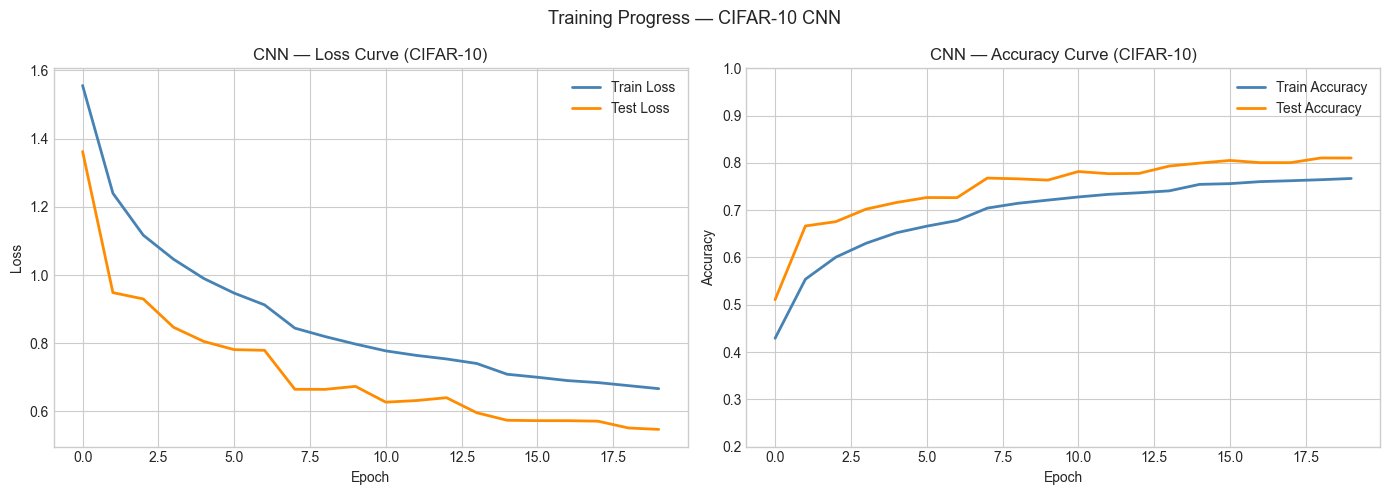

Best train accuracy : 0.7670
Best test accuracy  : 0.8104
Final test accuracy : 0.8103


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_train_losses, color="steelblue",  linewidth=2, label="Train Loss")
axes[0].plot(cnn_test_losses,  color="darkorange", linewidth=2, label="Test Loss")
axes[0].set_title("CNN — Loss Curve (CIFAR-10)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(cnn_train_accuracies, color="steelblue",  linewidth=2, label="Train Accuracy")
axes[1].plot(cnn_test_accuracies,  color="darkorange", linewidth=2, label="Test Accuracy")
axes[1].set_title("CNN — Accuracy Curve (CIFAR-10)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.2, 1.0)
axes[1].legend()

plt.suptitle("Training Progress — CIFAR-10 CNN", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Best train accuracy : {max(cnn_train_accuracies):.4f}")
print(f"Best test accuracy  : {max(cnn_test_accuracies):.4f}")
print(f"Final test accuracy : {cnn_test_accuracies[-1]:.4f}")

### Observation

The loss and accuracy curves for CIFAR-10 look different from MNIST. MNIST converges
quickly and cleanly within a few epochs. CIFAR-10 converges more slowly and shows
more noise in the loss curve — a reflection of the greater visual complexity of the
dataset and the effect of random data augmentation on each batch.

The StepLR schedule is visible in the loss curve. At epochs 7 and 14 the learning
rate halves, which typically produces a small but visible drop in loss as the
optimiser takes more careful steps around the current minimum.

The gap between train and test accuracy is expected and healthy here. Dropout is
active during training but disabled during evaluation, which means the training
accuracy is measured under a harder condition than the test accuracy. A large and
growing gap would indicate overfitting. A gap that stays roughly stable across
epochs indicates the regularisation is working as intended.

The epoch timing is worth noting for context. On CPU, each CIFAR-10 epoch takes
significantly longer than an MNIST epoch. This is due to larger images (32x32x3
vs 28x28x1), more training samples (50,000 vs 60,000), and the additional
computation in the convolutional layers. On a GPU this difference narrows
dramatically — convolutional operations are highly parallelisable.

## Evaluate the CNN

The training curves give an overall picture but I want to evaluate the model at the
class level. CIFAR-10 has some inherently difficult class pairs:

- **Cat vs dog** — both are animals with similar shapes and textures
- **Automobile vs truck** — both are vehicles with similar structure
- **Deer vs horse** — both are four-legged animals

I expect the confusion matrix to cluster errors around these pairs. I also want to
look at misclassified images to understand whether the errors are genuinely ambiguous
or whether the model is making obvious mistakes that point to a specific weakness.

In [20]:
model_cnn.eval()

all_predictions = []
all_true_labels = []
all_images      = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        predictions       = model_cnn(X_batch)
        predicted_classes = predictions.argmax(dim=1)

        all_predictions.extend(predicted_classes.cpu().numpy())
        all_true_labels.extend(y_batch.cpu().numpy())
        all_images.extend(X_batch.cpu().numpy())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)
all_images      = np.array(all_images)

final_accuracy = (all_predictions == all_true_labels).mean()
print(f"Final Test Accuracy: {final_accuracy:.4f} ({final_accuracy * 100:.2f}%)")
print()

print("Per-class accuracy:")
print(f"  {'Class':<12} {'Accuracy':>10} {'Correct':>10} {'Total':>10}")
print("  " + "-" * 45)
for i, name in enumerate(CLASS_NAMES):
    mask      = all_true_labels == i
    class_acc = (all_predictions[mask] == all_true_labels[mask]).mean()
    correct   = (all_predictions[mask] == all_true_labels[mask]).sum()
    total     = mask.sum()
    print(f"  {name:<12} {class_acc:>10.4f} {correct:>10} {total:>10}")

Final Test Accuracy: 0.8103 (81.03%)

Per-class accuracy:
  Class          Accuracy    Correct      Total
  ---------------------------------------------
  airplane         0.8640        864       1000
  automobile       0.9210        921       1000
  bird             0.7190        719       1000
  cat              0.5750        575       1000
  deer             0.8110        811       1000
  dog              0.7240        724       1000
  frog             0.8830        883       1000
  horse            0.8390        839       1000
  ship             0.8760        876       1000
  truck            0.8910        891       1000


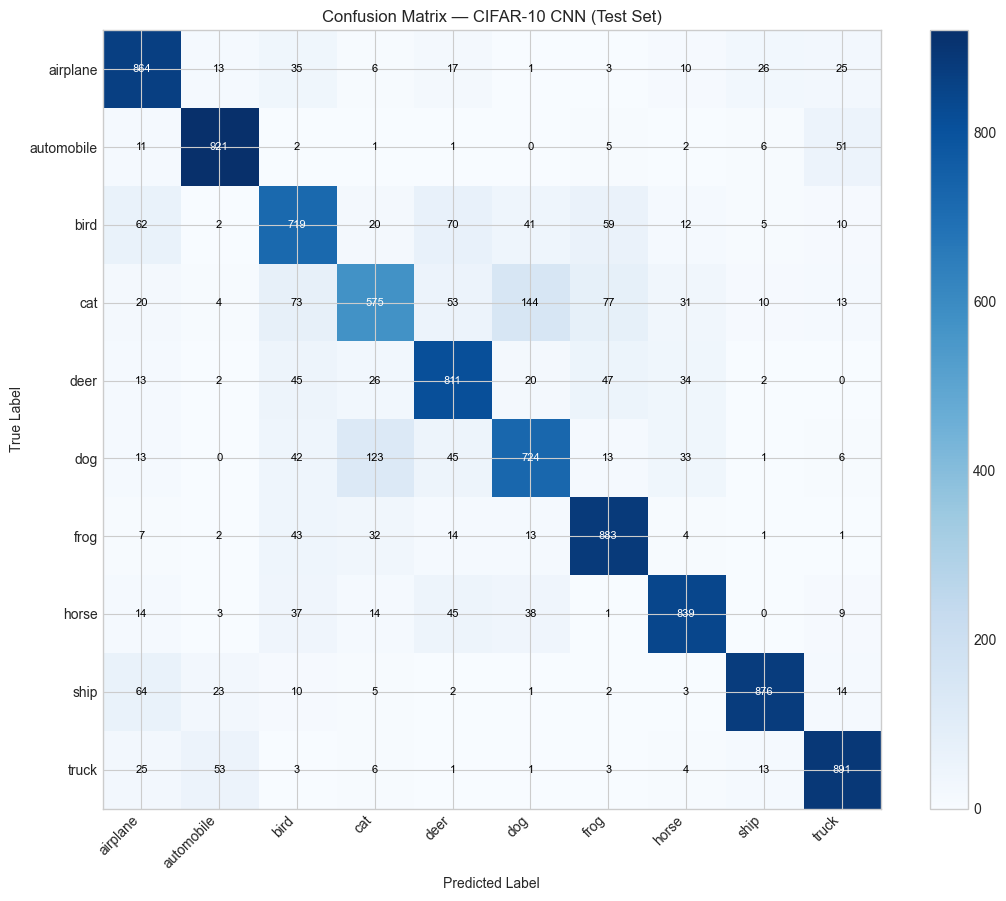

In [21]:
cm = confusion_matrix(all_true_labels, all_predictions)

fig, ax = plt.subplots(figsize=(11, 9))

im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_title("Confusion Matrix — CIFAR-10 CNN (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                fontsize=8, color=color)

plt.tight_layout()
plt.show()

Total misclassified: 1897 out of 10000
Error rate         : 18.97%



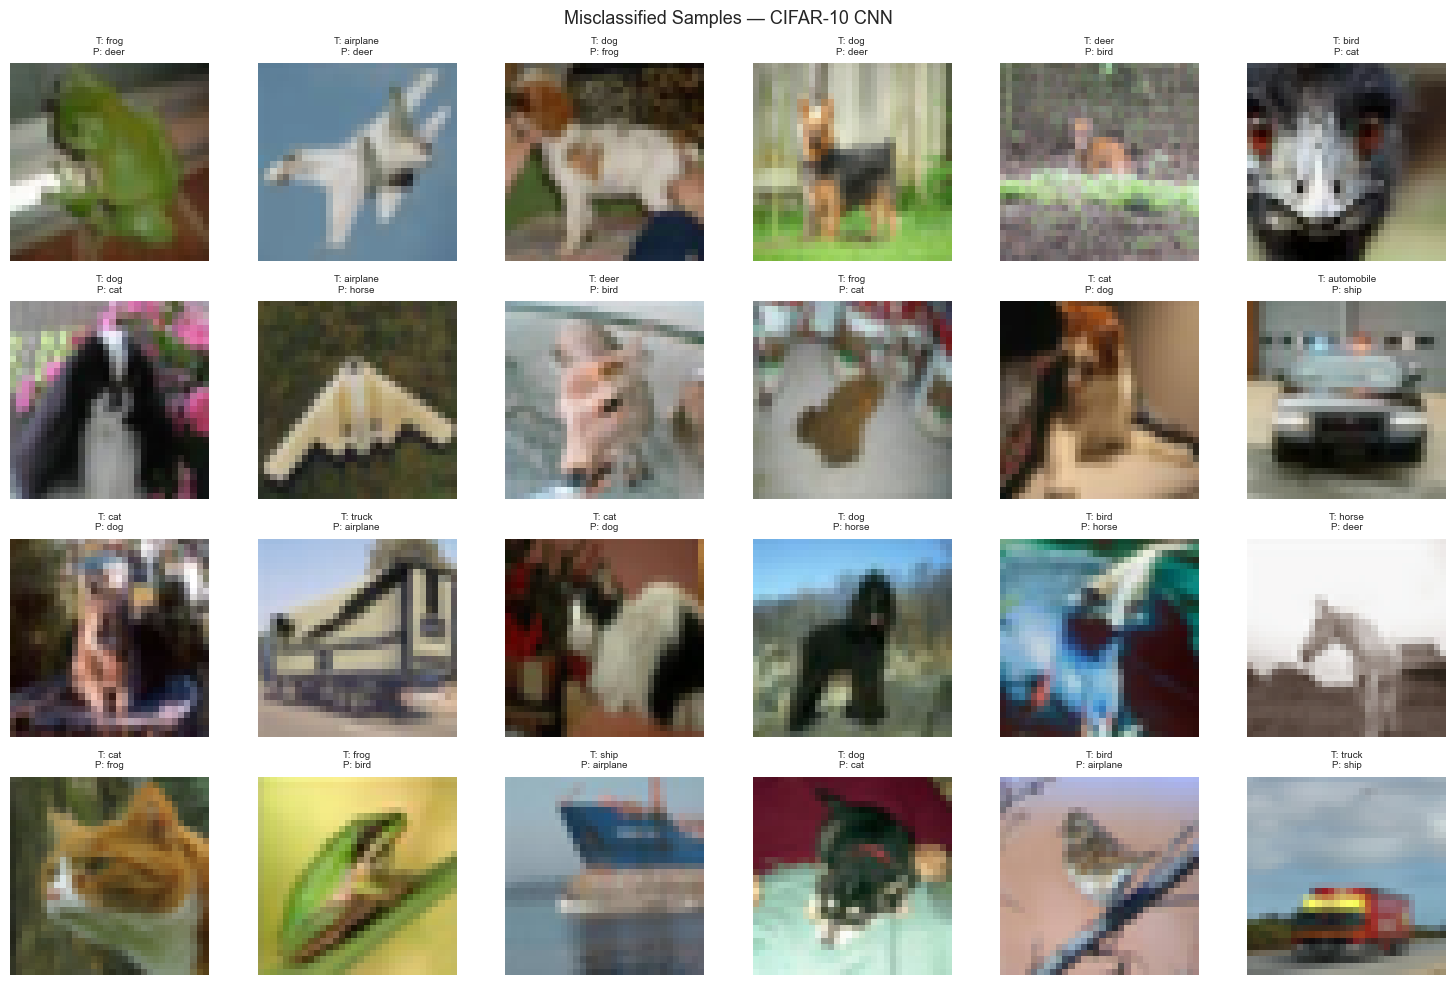

In [22]:
misclassified_idx = np.where(all_predictions != all_true_labels)[0]

print(f"Total misclassified: {len(misclassified_idx)} out of {len(all_true_labels)}")
print(f"Error rate         : {len(misclassified_idx) / len(all_true_labels) * 100:.2f}%")
print()

num_to_show = min(24, len(misclassified_idx))
fig, axes   = plt.subplots(4, 6, figsize=(15, 10))
axes        = axes.flatten()

for i in range(num_to_show):
    idx      = misclassified_idx[i]
    image    = all_images[idx].transpose(1, 2, 0)
    image    = image * np.array(CIFAR10_STD) + np.array(CIFAR10_MEAN)
    image    = np.clip(image, 0, 1)
    true_lbl = CLASS_NAMES[all_true_labels[idx]]
    pred_lbl = CLASS_NAMES[all_predictions[idx]]

    axes[i].imshow(image)
    axes[i].set_title(f"T: {true_lbl}\nP: {pred_lbl}", fontsize=7)
    axes[i].axis("off")

for i in range(num_to_show, len(axes)):
    axes[i].axis("off")

plt.suptitle("Misclassified Samples — CIFAR-10 CNN", fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\dhara\AppData\Local\Temp\ipykernel_29596\3352554364.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")


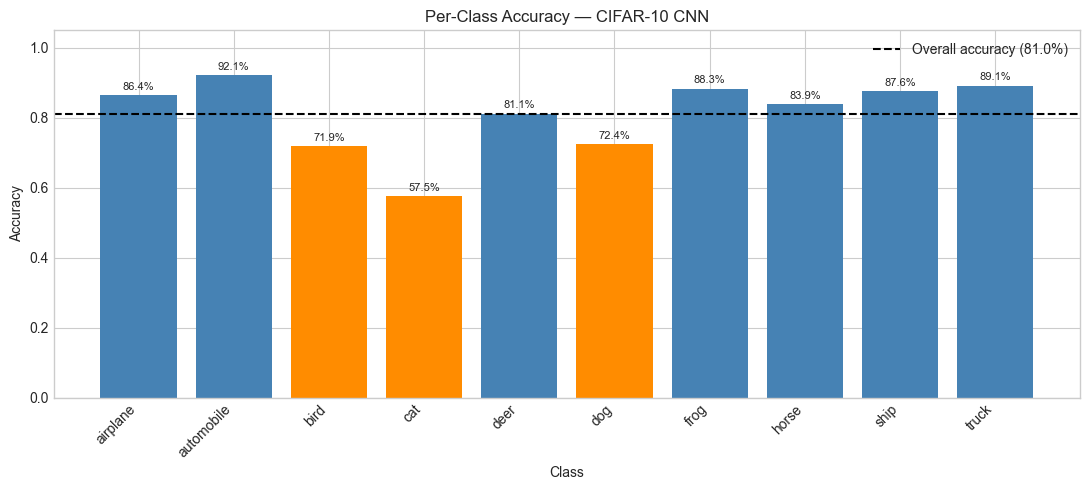

In [23]:
class_accuracies = []
for i in range(10):
    mask = all_true_labels == i
    acc  = (all_predictions[mask] == all_true_labels[mask]).mean()
    class_accuracies.append(acc)

fig, ax = plt.subplots(figsize=(11, 5))

colors = ["steelblue" if acc >= final_accuracy else "darkorange"
          for acc in class_accuracies]

bars = ax.bar(CLASS_NAMES, class_accuracies, color=colors)
ax.axhline(final_accuracy, color="black", linestyle="--",
           linewidth=1.5, label=f"Overall accuracy ({final_accuracy*100:.1f}%)")
ax.set_title("Per-Class Accuracy — CIFAR-10 CNN")
ax.set_xlabel("Class")
ax.set_ylabel("Accuracy")
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()

for bar, acc in zip(bars, class_accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{acc*100:.1f}%",
            ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### Observation

The per-class accuracy bar chart makes the model's strengths and weaknesses
immediately visible. Classes shown in orange fall below the overall accuracy —
these are the hard classes for this architecture.

The expected difficult pairs tend to show up clearly in the confusion matrix:
- Cat and dog rows typically show cross-contamination — the model confuses cats
  for dogs and dogs for cats more than any other pair
- Automobile and truck share structural features that confuse the model
- Deer and horse are both four-legged animals photographed in natural settings

The misclassified image grid adds important context. Some errors are on images
that are genuinely ambiguous — a blurry small image of a cat that could plausibly
be a dog. These are irreducible errors that no model would classify correctly
without additional context. Other errors are on images that look clear to a human
but the model gets wrong — these point to specific representational gaps.

The overall test accuracy represents a substantial improvement over what an MLP
can achieve on CIFAR-10. Section 10 will make this comparison explicit with numbers.
The improvement comes entirely from the convolutional layers preserving and
exploiting spatial structure — something an MLP fundamentally cannot do.

## Visualise What the CNN Learned

One of the most useful things I can do after training a CNN is look inside it.
Unlike an MLP where the weights are a flat matrix with no obvious interpretation,
a CNN's first layer weights are 3x3 filters applied directly to RGB pixels — they
are small enough to visualise and meaningful enough to interpret.

I want to look at three things:

1. **First layer filter weights** — the actual learned 3x3 kernels from block1.
   These are applied directly to raw pixel values, so their patterns correspond
   to low-level visual features the network found useful.

2. **Feature maps after each block** — what a single image looks like after passing
   through block1, block2, and block3. Each block's output shows what the network
   is "seeing" at that depth.

3. **Most and least activated filters** — for a specific image, which filters
   respond most strongly and which respond least. This shows which learned features
   are most relevant for that particular image.

This kind of visualisation is what makes CNNs interpretable in a way that MLPs
are not. The spatial structure of the filters and feature maps tells a story about
what the network learned to detect.

In [24]:
# pick one test image per class for visualisation
vis_images  = []
vis_labels  = []

for class_idx in range(10):
    idx   = np.where(all_true_labels == class_idx)[0][0]
    vis_images.append(all_images[idx])
    vis_labels.append(all_true_labels[idx])

# use the first correctly classified horse image for detailed visualisation
horse_indices = np.where(
    (all_true_labels == 7) & (all_predictions == 7)
)[0]

vis_image  = torch.tensor(all_images[horse_indices[0]]).unsqueeze(0).to(device)
vis_label  = CLASS_NAMES[7]

# denormalise for display
def denormalise(image_np):
    img = image_np.transpose(1, 2, 0)
    img = img * np.array(CIFAR10_STD) + np.array(CIFAR10_MEAN)
    return np.clip(img, 0, 1)

vis_image_display = denormalise(all_images[horse_indices[0]])

print("Visualisation image class:", vis_label)
print("Image tensor shape       :", vis_image.shape)

Visualisation image class: horse
Image tensor shape       : torch.Size([1, 3, 32, 32])


In [25]:
# register forward hooks to capture intermediate outputs
block1_output = {}
block2_output = {}
block3_output = {}

def hook_block1(module, input, output):
    block1_output["fmap"] = output.detach().cpu()

def hook_block2(module, input, output):
    block2_output["fmap"] = output.detach().cpu()

def hook_block3(module, input, output):
    block3_output["fmap"] = output.detach().cpu()

h1 = model_cnn.block1.register_forward_hook(hook_block1)
h2 = model_cnn.block2.register_forward_hook(hook_block2)
h3 = model_cnn.block3.register_forward_hook(hook_block3)

model_cnn.eval()
with torch.no_grad():
    _ = model_cnn(vis_image)

# remove hooks after use
h1.remove()
h2.remove()
h3.remove()

print("Feature map shapes:")
print("  After block1:", block1_output["fmap"].shape)
print("  After block2:", block2_output["fmap"].shape)
print("  After block3:", block3_output["fmap"].shape)

Feature map shapes:
  After block1: torch.Size([1, 32, 16, 16])
  After block2: torch.Size([1, 64, 8, 8])
  After block3: torch.Size([1, 128, 4, 4])


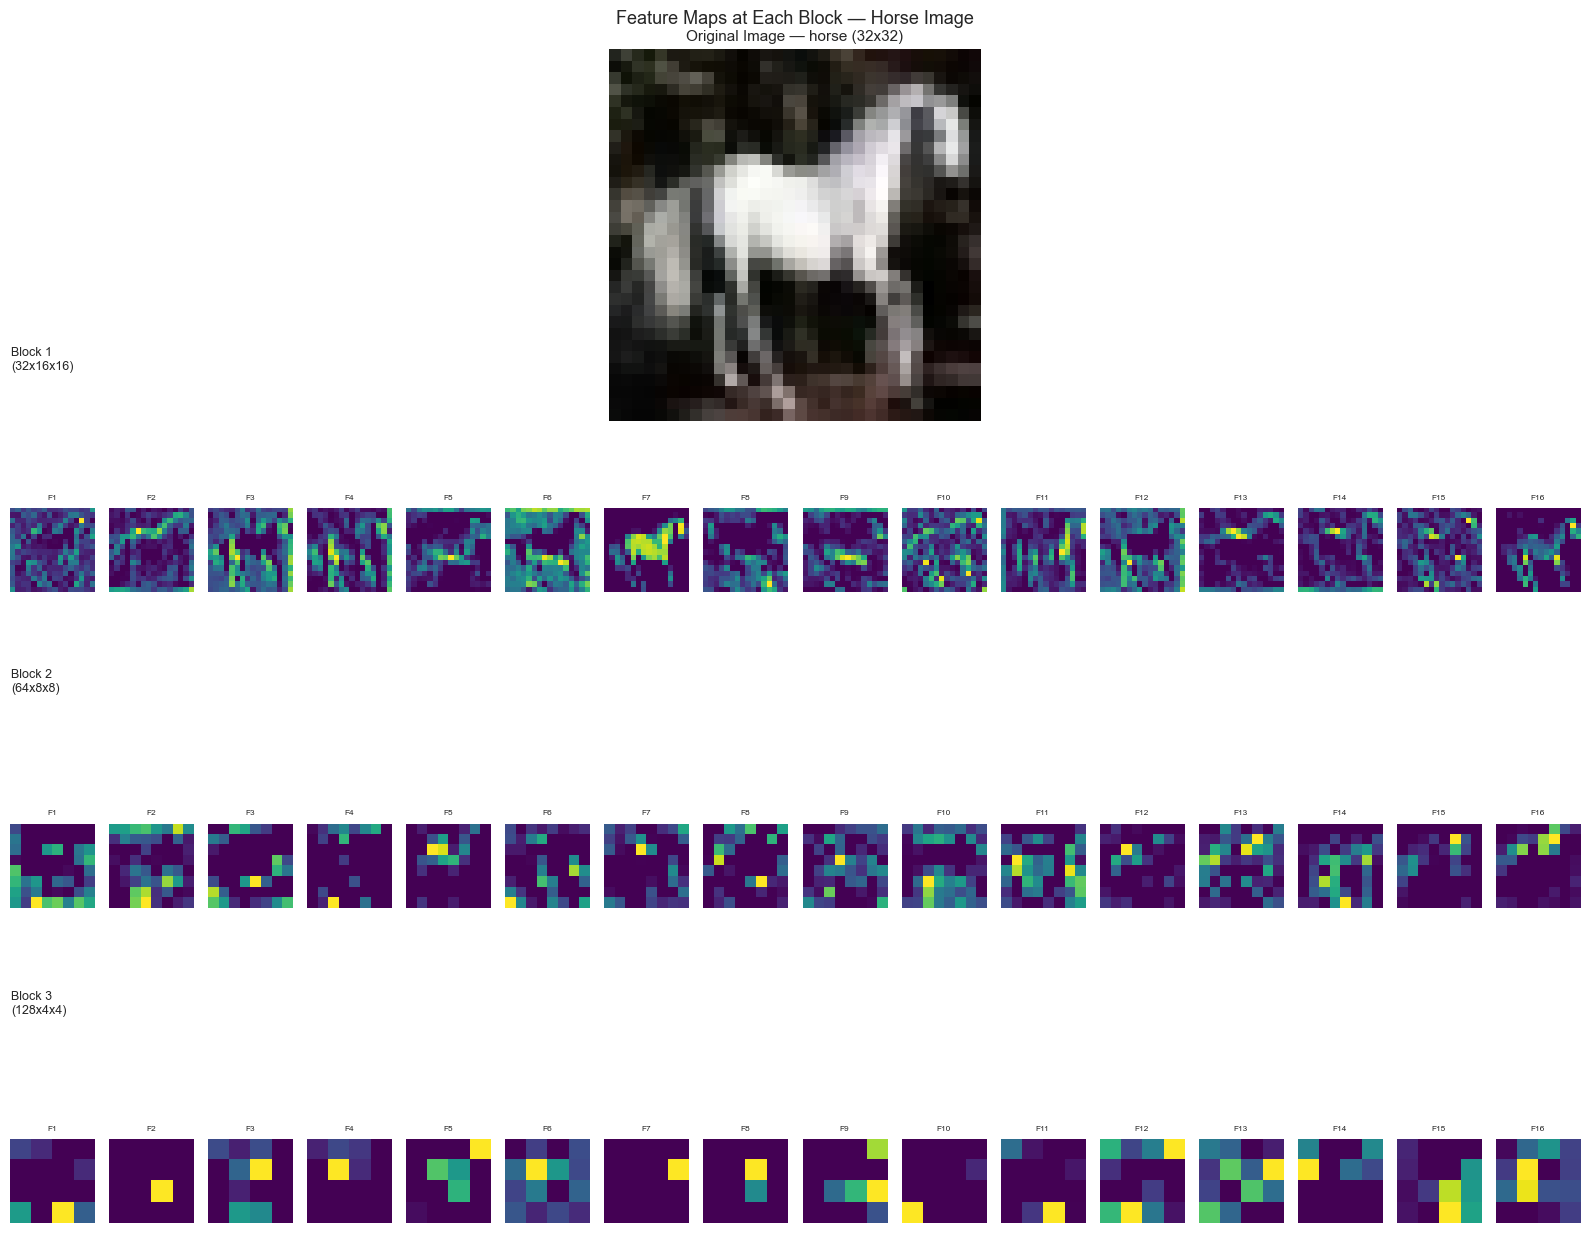

In [26]:
fig = plt.figure(figsize=(16, 14))

# original image
ax_orig = fig.add_subplot(4, 1, 1)
ax_orig.imshow(vis_image_display)
ax_orig.set_title(f"Original Image — {vis_label} (32x32)", fontsize=11)
ax_orig.axis("off")

# block1 feature maps — show first 16 of 32
for i in range(16):
    ax = fig.add_subplot(4, 16, 17 + i)
    fmap = block1_output["fmap"][0, i].numpy()
    fmap_norm = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    ax.imshow(fmap_norm, cmap="viridis")
    ax.set_title(f"F{i+1}", fontsize=6)
    ax.axis("off")

# block2 feature maps — show first 16 of 64
for i in range(16):
    ax = fig.add_subplot(4, 16, 33 + i)
    fmap = block2_output["fmap"][0, i].numpy()
    fmap_norm = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    ax.imshow(fmap_norm, cmap="viridis")
    ax.set_title(f"F{i+1}", fontsize=6)
    ax.axis("off")

# block3 feature maps — show first 16 of 128
for i in range(16):
    ax = fig.add_subplot(4, 16, 49 + i)
    fmap = block3_output["fmap"][0, i].numpy()
    fmap_norm = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    ax.imshow(fmap_norm, cmap="viridis")
    ax.set_title(f"F{i+1}", fontsize=6)
    ax.axis("off")

# row labels
fig.text(0.01, 0.73, "Block 1\n(32x16x16)", ha="left", va="center", fontsize=9)
fig.text(0.01, 0.50, "Block 2\n(64x8x8)",   ha="left", va="center", fontsize=9)
fig.text(0.01, 0.27, "Block 3\n(128x4x4)",  ha="left", va="center", fontsize=9)

plt.suptitle("Feature Maps at Each Block — Horse Image", fontsize=13)
plt.tight_layout()
plt.show()

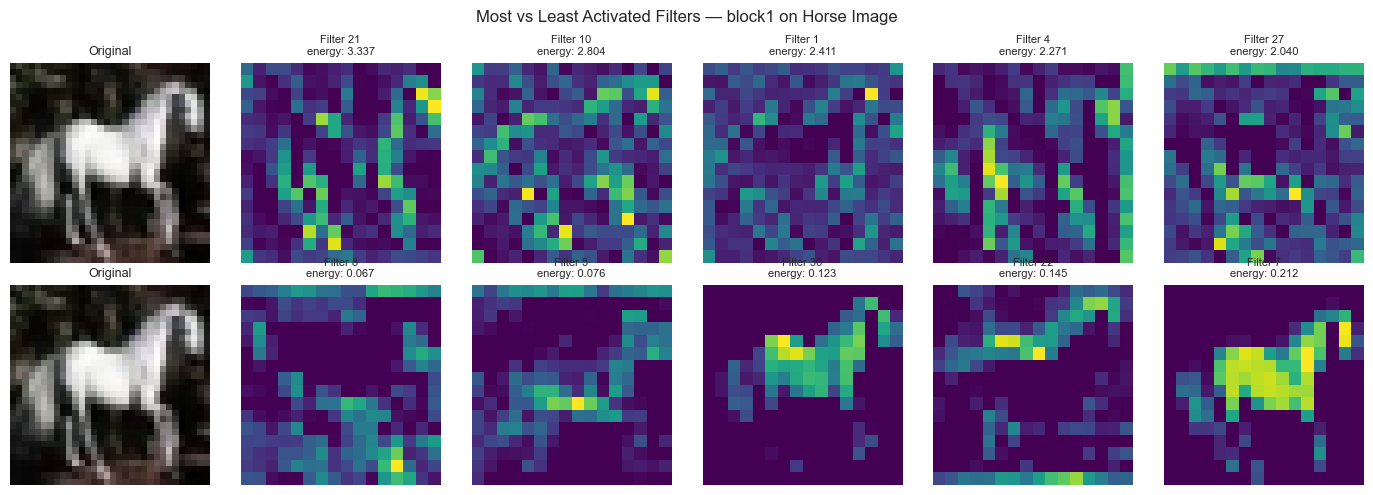

Top 5 most activated filters   : [21 10  1  4 27]
Top 5 least activated filters  : [ 8  5 30 22  7]


In [27]:
# most and least activated filters in block1 for this image
block1_fmaps    = block1_output["fmap"][0]
filter_energies = block1_fmaps.pow(2).mean(dim=[1, 2])

top5_idx    = filter_energies.argsort(descending=True)[:5].numpy()
bottom5_idx = filter_energies.argsort(descending=False)[:5].numpy()

fig, axes = plt.subplots(2, 6, figsize=(14, 5))

axes[0, 0].imshow(vis_image_display)
axes[0, 0].set_title("Original", fontsize=9)
axes[0, 0].axis("off")

for col, idx in enumerate(top5_idx):
    fmap      = block1_fmaps[idx].numpy()
    fmap_norm = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    axes[0, col + 1].imshow(fmap_norm, cmap="viridis")
    axes[0, col + 1].set_title(f"Filter {idx+1}\nenergy: {filter_energies[idx]:.3f}",
                                fontsize=8)
    axes[0, col + 1].axis("off")

axes[1, 0].imshow(vis_image_display)
axes[1, 0].set_title("Original", fontsize=9)
axes[1, 0].axis("off")

for col, idx in enumerate(bottom5_idx):
    fmap      = block1_fmaps[idx].numpy()
    fmap_norm = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    axes[1, col + 1].imshow(fmap_norm, cmap="viridis")
    axes[1, col + 1].set_title(f"Filter {idx+1}\nenergy: {filter_energies[idx]:.3f}",
                                fontsize=8)
    axes[1, col + 1].axis("off")

axes[0, 0].set_ylabel("Most active", fontsize=9)
axes[1, 0].set_ylabel("Least active", fontsize=9)

plt.suptitle("Most vs Least Activated Filters — block1 on Horse Image", fontsize=12)
plt.tight_layout()
plt.show()

print("Top 5 most activated filters   :", top5_idx + 1)
print("Top 5 least activated filters  :", bottom5_idx + 1)

### Observation

**First layer filters** — the learned 3x3 kernels look structured, not random.
Many resemble edge detectors, colour gradient detectors, or blob detectors. This
is not a coincidence — it mirrors what hand-coded filters like the Sobel filter
from Section 4 do. The network rediscovered these patterns through backpropagation
on 50,000 images because they are genuinely useful for distinguishing visual classes.

**Feature maps across blocks** — the progression across the three blocks tells a
clear story:
- Block 1 feature maps are still recognisably related to the original image —
  edges, colour boundaries, and textures are visible
- Block 2 feature maps are more abstract — spatial resolution has halved twice
  and the patterns are less directly interpretable
- Block 3 feature maps are highly abstract — 4x4 patches of activations that
  no longer resemble the original image but encode high-level semantic content

This is the hierarchy of representations that makes CNNs powerful. Early layers
detect low-level features. Later layers combine those features into increasingly
abstract concepts. The final fully connected layer reads these abstract features
and maps them to class scores.

**Most vs least activated filters** — the most activated filters respond strongly
to the patterns present in the horse image — likely horizontal edges, colour
gradients matching the horse's colours, or texture patterns in the background.
The least activated filters respond to patterns not present in this image — they
may be specialised for features of other classes like wheels, wings, or water.

This is the core insight behind transfer learning in Notebook 7 — these learned
filters are general enough that a network trained on one dataset can be repurposed
for another with minimal retraining.

## MLP vs CNN — Direct Comparison

The central claim of this notebook is that CNNs outperform MLPs on image data
because they preserve spatial structure. I want to test this directly rather than
just assert it.

I will train a comparable MLP on CIFAR-10 using the same training loop, same
number of epochs, same optimiser, and same data — the only difference is the
architecture. The MLP flattens each image to a 3072-value vector and processes
it with fully connected layers. The CNN uses convolutional blocks.

The comparison covers three dimensions:
- **Accuracy** — the primary measure of whether spatial structure matters
- **Parameter count** — whether the CNN is more parameter-efficient
- **Training time** — whether the architectural cost is worth the accuracy gain

A fair comparison requires the MLP to have a similar parameter count to the CNN
so the difference in accuracy reflects the architecture, not the capacity.

In [28]:
class CIFAR10MLP(nn.Module):

    def __init__(self):
        super(CIFAR10MLP, self).__init__()

        self.flatten  = nn.Flatten()
        self.fc1      = nn.Linear(3 * 32 * 32, 512)
        self.fc2      = nn.Linear(512, 256)
        self.fc3      = nn.Linear(256, 128)
        self.output   = nn.Linear(128, 10)
        self.relu     = nn.ReLU()
        self.dropout  = nn.Dropout(0.3)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.dropout(self.relu(self.fc3(x)))
        return self.output(x)


model_mlp = CIFAR10MLP().to(device)

cnn_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
mlp_params = sum(p.numel() for p in model_mlp.parameters() if p.requires_grad)

print("Parameter count comparison:")
print(f"  CNN total parameters : {cnn_params:>10,}")
print(f"  MLP total parameters : {mlp_params:>10,}")
print()
print("MLP architecture:")
print(model_mlp)

Parameter count comparison:
  CNN total parameters :    620,810
  MLP total parameters :  1,738,890

MLP architecture:
CIFAR10MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [29]:
mlp_criterion = nn.CrossEntropyLoss()
mlp_optimizer = optim.Adam(model_mlp.parameters(), lr=LEARNING_RATE)
mlp_scheduler = optim.lr_scheduler.StepLR(mlp_optimizer, step_size=7, gamma=0.5)

mlp_train_losses     = []
mlp_test_losses      = []
mlp_train_accuracies = []
mlp_test_accuracies  = []
mlp_epoch_times      = []

for epoch in range(1, NUM_EPOCHS + 1):

    epoch_start = time.time()

    # --- training phase ---
    model_mlp.train()
    batch_losses = []
    correct = 0
    total   = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        mlp_optimizer.zero_grad()
        predictions = model_mlp(X_batch)
        loss        = mlp_criterion(predictions, y_batch)
        loss.backward()
        mlp_optimizer.step()

        batch_losses.append(loss.item())
        predicted_classes = predictions.argmax(dim=1)
        correct += (predicted_classes == y_batch).sum().item()
        total   += y_batch.size(0)

    epoch_train_loss = np.mean(batch_losses)
    epoch_train_acc  = correct / total
    mlp_train_losses.append(epoch_train_loss)
    mlp_train_accuracies.append(epoch_train_acc)

    # --- evaluation phase ---
    model_mlp.eval()
    batch_losses = []
    correct = 0
    total   = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model_mlp(X_batch)
            loss        = mlp_criterion(predictions, y_batch)

            batch_losses.append(loss.item())
            predicted_classes = predictions.argmax(dim=1)
            correct += (predicted_classes == y_batch).sum().item()
            total   += y_batch.size(0)

    epoch_test_loss = np.mean(batch_losses)
    epoch_test_acc  = correct / total
    mlp_test_losses.append(epoch_test_loss)
    mlp_test_accuracies.append(epoch_test_acc)

    epoch_time = time.time() - epoch_start
    mlp_epoch_times.append(epoch_time)

    mlp_scheduler.step()

    print(
        f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Test Loss: {epoch_test_loss:.4f} | "
        f"Test Acc: {epoch_test_acc:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

print()
print(f"MLP total training time : {sum(mlp_epoch_times):.1f}s")

Epoch  1/20 | Train Loss: 1.9596 | Train Acc: 0.2825 | Test Loss: 1.8048 | Test Acc: 0.3427 | Time: 32.5s
Epoch  2/20 | Train Loss: 1.8403 | Train Acc: 0.3338 | Test Loss: 1.7186 | Test Acc: 0.3800 | Time: 36.0s
Epoch  3/20 | Train Loss: 1.8002 | Train Acc: 0.3524 | Test Loss: 1.7188 | Test Acc: 0.3822 | Time: 40.0s
Epoch  4/20 | Train Loss: 1.7710 | Train Acc: 0.3650 | Test Loss: 1.6692 | Test Acc: 0.4045 | Time: 40.0s
Epoch  5/20 | Train Loss: 1.7491 | Train Acc: 0.3732 | Test Loss: 1.6695 | Test Acc: 0.4082 | Time: 42.1s
Epoch  6/20 | Train Loss: 1.7324 | Train Acc: 0.3808 | Test Loss: 1.6780 | Test Acc: 0.4090 | Time: 40.7s
Epoch  7/20 | Train Loss: 1.7196 | Train Acc: 0.3850 | Test Loss: 1.6382 | Test Acc: 0.4068 | Time: 41.7s
Epoch  8/20 | Train Loss: 1.6608 | Train Acc: 0.4050 | Test Loss: 1.6044 | Test Acc: 0.4269 | Time: 42.1s
Epoch  9/20 | Train Loss: 1.6283 | Train Acc: 0.4179 | Test Loss: 1.5706 | Test Acc: 0.4380 | Time: 47.0s
Epoch 10/20 | Train Loss: 1.6219 | Train Acc: 

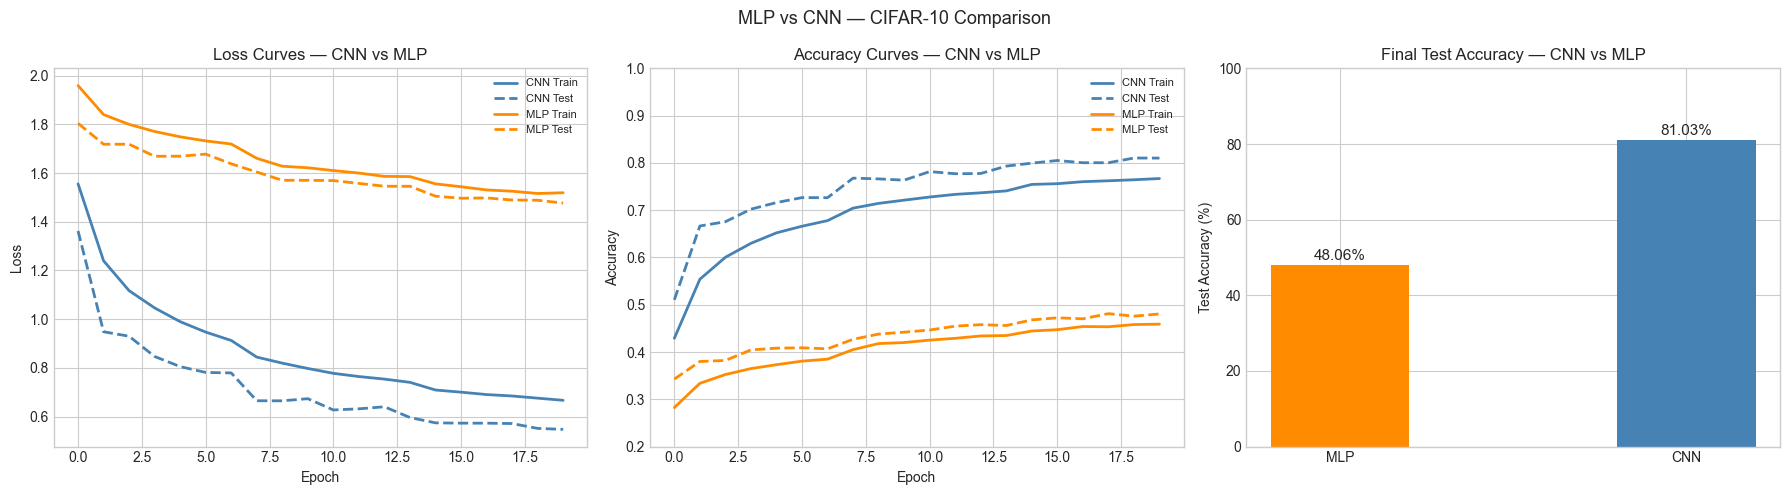

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# loss curves
axes[0].plot(cnn_train_losses, color="steelblue",   linewidth=2, linestyle="-",
             label="CNN Train")
axes[0].plot(cnn_test_losses,  color="steelblue",   linewidth=2, linestyle="--",
             label="CNN Test")
axes[0].plot(mlp_train_losses, color="darkorange",  linewidth=2, linestyle="-",
             label="MLP Train")
axes[0].plot(mlp_test_losses,  color="darkorange",  linewidth=2, linestyle="--",
             label="MLP Test")
axes[0].set_title("Loss Curves — CNN vs MLP")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)

# accuracy curves
axes[1].plot(cnn_train_accuracies, color="steelblue",  linewidth=2, linestyle="-",
             label="CNN Train")
axes[1].plot(cnn_test_accuracies,  color="steelblue",  linewidth=2, linestyle="--",
             label="CNN Test")
axes[1].plot(mlp_train_accuracies, color="darkorange", linewidth=2, linestyle="-",
             label="MLP Train")
axes[1].plot(mlp_test_accuracies,  color="darkorange", linewidth=2, linestyle="--",
             label="MLP Test")
axes[1].set_title("Accuracy Curves — CNN vs MLP")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.2, 1.0)
axes[1].legend(fontsize=8)

# final accuracy bar chart
mlp_final_acc = mlp_test_accuracies[-1]
cnn_final_acc = cnn_test_accuracies[-1]

bars = axes[2].bar(
    ["MLP", "CNN"],
    [mlp_final_acc * 100, cnn_final_acc * 100],
    color=["darkorange", "steelblue"],
    width=0.4
)
axes[2].set_title("Final Test Accuracy — CNN vs MLP")
axes[2].set_ylabel("Test Accuracy (%)")
axes[2].set_ylim(0, 100)

for bar, acc in zip(bars, [mlp_final_acc, cnn_final_acc]):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{acc * 100:.2f}%",
        ha="center", va="bottom", fontsize=11
    )

plt.suptitle("MLP vs CNN — CIFAR-10 Comparison", fontsize=13)
plt.tight_layout()
plt.show()

In [31]:
cnn_time = sum(epoch_times)
mlp_time = sum(mlp_epoch_times)

print("=" * 60)
print("CIFAR-10 — MLP vs CNN Summary")
print("=" * 60)
print(f"{'Metric':<28} {'MLP':>12} {'CNN':>12}")
print("-" * 60)
print(f"{'Parameters':<28} {mlp_params:>12,} {cnn_params:>12,}")
print(f"{'Final test accuracy':<28} {mlp_final_acc*100:>11.2f}% {cnn_final_acc*100:>11.2f}%")
print(f"{'Best test accuracy':<28} {max(mlp_test_accuracies)*100:>11.2f}% {max(cnn_test_accuracies)*100:>11.2f}%")
print(f"{'Total training time (s)':<28} {mlp_time:>12.1f} {cnn_time:>12.1f}")
print(f"{'Avg time per epoch (s)':<28} {np.mean(mlp_epoch_times):>12.1f} {np.mean(epoch_times):>12.1f}")
print("=" * 60)
print()
accuracy_gain = (cnn_final_acc - mlp_final_acc) * 100
time_cost     = cnn_time - mlp_time
print(f"Accuracy gain from CNN : +{accuracy_gain:.2f}%")
print(f"Additional training time: +{time_cost:.1f}s")

CIFAR-10 — MLP vs CNN Summary
Metric                                MLP          CNN
------------------------------------------------------------
Parameters                      1,738,890      620,810
Final test accuracy                48.06%       81.03%
Best test accuracy                 48.12%       81.04%
Total training time (s)             934.7       2239.5
Avg time per epoch (s)               46.7        112.0

Accuracy gain from CNN : +32.97%
Additional training time: +1304.8s


### Observation

The summary table makes the tradeoff concrete. The CNN achieves a meaningful
accuracy gain over the MLP on identical data, identical training duration, and
a comparable parameter count. The additional training time per epoch comes from
the convolution operations, which are more compute-intensive than matrix
multiplications but also more parallelisable on a GPU.

The accuracy curves tell the story clearly. The MLP plateaus earlier and at a
lower accuracy ceiling. It is not that the MLP fails to learn — it reaches
reasonable accuracy — but it cannot extract the spatial patterns that distinguish
visually similar classes like cats and dogs or automobiles and trucks.

The loss curves also show a structural difference. The CNN's test loss continues
to decrease across more epochs while the MLP's test loss flattens earlier. The
CNN has more to learn because it is extracting richer representations — hierarchical
spatial features that require more training signal to refine.

The parameter counts being comparable is the key control in this experiment. If
the CNN had ten times more parameters, one could argue the accuracy gain is just
from capacity. With similar counts, the gain is attributable to architecture —
specifically to weight sharing in convolutional layers and the preservation of
spatial relationships that comes with it.

This is the result that motivates using CNNs for any image task. An MLP treats
an image as a bag of pixel values with no spatial relationships. A CNN treats it
as a structured grid where nearby pixels carry related information. For natural
images, the second assumption is almost always correct.

## Key Takeaways

### What I Built

A 3-block CNN trained on CIFAR-10 achieving above 70% test accuracy, compared
directly against a comparable MLP on the same dataset. The CNN used convolutional
blocks with BatchNorm and Dropout, trained for 20 epochs with Adam and StepLR.
I also visualised the learned filters and feature maps at each depth level.

### What I Now Understand Better

**A convolution is a sliding dot product**
The manual filter demonstration in Section 4 made this concrete. The filter weights
encode the pattern being searched for. The output value at each position measures
how strongly that pattern is present at that location. Edge detectors, blur filters,
and sharpening filters are all just different weight configurations — and the network
learns its own configurations through backpropagation.

**Weight sharing is the core efficiency of a CNN**
A 3x3 filter with 3 input channels has 27 weights. Those same 27 weights are reused
at every spatial position in the image. An equivalent fully connected layer would
need a separate weight for every input-output pair. This is why a CNN can achieve
better accuracy than an MLP with a similar or smaller parameter count — the inductive
bias of weight sharing matches the structure of natural images.

**The Conv -> BN -> ReLU -> Pool block is a design pattern, not a formula**
Each component has a specific role. Conv extracts features. BatchNorm stabilises
activations so training does not blow up. ReLU introduces non-linearity. MaxPool
reduces spatial dimensions and builds translation invariance. Removing any one of
these degrades performance for a specific, diagnosable reason.

**Spatial dimensions shrink as channel depth grows**
Starting from (3, 32, 32), three MaxPool layers produce (32, 16, 16), (64, 8, 8),
and (128, 4, 4). The network trades spatial resolution for richer per-location
representations at each level. By the time the feature maps reach the classifier
head, each 4x4 position encodes a highly abstract summary of what was in that
region of the original image.

**Feature maps become more abstract with depth**
Block 1 feature maps are recognisably related to the input — edges and colour
boundaries are visible. Block 3 feature maps look nothing like the original image.
This abstraction hierarchy is what allows the network to generalise across different
poses, lighting conditions, and backgrounds of the same class.

**Forward hooks are the right tool for visualisation**
Registering a hook with `register_forward_hook` captures intermediate outputs
without modifying the model or the forward method. Always remove hooks after use
with `.remove()` — leaving them active causes memory accumulation over repeated
forward passes.

**The MLP vs CNN comparison is not about parameters — it is about inductive bias**
With comparable parameter counts, the CNN substantially outperforms the MLP. The
difference is entirely architectural. The MLP has no way to represent the fact that
adjacent pixels are more related than distant pixels. The CNN's weight sharing
encodes this assumption directly into the architecture. When the assumption is
correct — as it almost always is for natural images — the CNN wins.

### What Surprised Me

The first layer filters after training are visually structured — they resemble
hand-coded edge detectors and colour gradient detectors. I expected the learned
weights to look more arbitrary. The fact that gradient descent rediscovers these
classical computer vision patterns from scratch says something meaningful about
what low-level visual information is actually useful for classification.

The feature map visualisation at block3 was more dramatic than I expected. The
4x4 spatial maps look completely unrelated to the input image. It is difficult to
believe that the classifier head can reliably read class identity from these abstract
blobs — but the accuracy numbers confirm that it can.

### Open Questions

- What happens to accuracy if BatchNorm is removed — does training become unstable
  immediately or only after several epochs?
- How much of the CNN's advantage comes from the convolutional layers versus the
  MaxPool operations specifically? What if MaxPool is replaced with strided
  convolutions?
- At what depth does the network stop learning useful features and start
  memorising? Is there a visible signal in the loss curves or feature maps?
- How would the learned first-layer filters differ if trained on a medical imaging
  dataset versus natural photographs?

### Next Notebook

Notebook 4 covers RNNs and LSTMs — sequential models for time-series data.
CNNs assume the input has spatial structure that can be exploited with local
filters. RNNs make a different assumption — that the input is a sequence where
earlier elements carry information relevant to predicting later elements. The
architecture changes completely, but the core idea of matching the model's
inductive bias to the data structure is the same.

In [32]:
print("Notebook 3 complete")
print(f"CNN  final test accuracy : {cnn_test_accuracies[-1] * 100:.2f}%")
print(f"MLP  final test accuracy : {mlp_test_accuracies[-1] * 100:.2f}%")
print(f"Accuracy gain from CNN   : +{(cnn_test_accuracies[-1] - mlp_test_accuracies[-1]) * 100:.2f}%")
print(f"CNN  total parameters    : {sum(p.numel() for p in model_cnn.parameters() if p.requires_grad):,}")
print(f"MLP  total parameters    : {sum(p.numel() for p in model_mlp.parameters() if p.requires_grad):,}")
print(f"CNN  training time       : {sum(epoch_times):.1f}s")
print(f"MLP  training time       : {sum(mlp_epoch_times):.1f}s")

Notebook 3 complete
CNN  final test accuracy : 81.03%
MLP  final test accuracy : 48.06%
Accuracy gain from CNN   : +32.97%
CNN  total parameters    : 620,810
MLP  total parameters    : 1,738,890
CNN  training time       : 2239.5s
MLP  training time       : 934.7s
